## Problem Statement
Diabetes mellitus is a growing public health problem in Uganda and across Africa, with the World Health Organization reporting an increase in cases due to lifestyle changes and limited early screening. Late diagnosis often leads to serious complications such as kidney failure, blindness, heart disease, and amputations, putting immense pressure on patients, families, and the healthcare system.

This project addresses the real-world problem of early diabetes risk prediction using machine learning. Using patient clinical data (such as glucose levels, BMI, age, and insulin), we  built a supervised binary classification model that predicts whether a patient is likely to have diabetes (Outcome = 1) or not (Outcome = 0).


# Why this problem matters
Early detection allows for timely lifestyle interventions, dietary changes, and medical follow-up, which can significantly reduce complications and healthcare costs.


# Stakeholders

Healthcare providers and hospitals in Uganda
Patients and their families
Public health officials and the Ministry of Health

# Decisions that can be improved
A machine learning solution can directly improve critical clinical and public-health decisions by providing fast, data-driven risk scores instead of relying only on manual assessment or expensive lab tests.

# Project Objectives

Acquire, explore, and preprocess a suitable diabetes dataset.

Build, train, and tune two to three classification models to predict diabetes risk.

Evaluate the models rigorously and provide actionable insights for real-world use in Ugandan healthcare settings.

### (b) Dataset Acquisition

 The dataset used is the **Pima Indians Diabetes Dataset**.  

 It meets all requirements:  
   - 768 records (rows)  
   - 9 features (columns) with a mix of numeric and binary variables  
   - Clear target variable: `Outcome` (0 = non-diabetic, 1 = diabetic)  

 **Full citation and URL**  
Smith, J.W., Everhart, J.E., Dickson, W.C., Knowler, W.C., & Johannes, R.S. (1988). Using the ADAP learning algorithm to forecast the onset of diabetes mellitus. In Proceedings of the Symposium on Computer Applications and Medical Care (pp. 261-265). IEEE Computer Society.  

**URL**: https://www.kaggle.com/datasets/uciml/pima-indians-diabetes-database  


### Loading the dataset

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt


In [2]:

df = pd.read_csv("pima_diabetes_data.csv")
df.head(10)

,Pregnancies,Glucose,BloodPressure,SkinThickness,Insulin,BMI,DiabetesPedigreeFunction,Age,Outcome
0,6,148,72,35,0,33.6,0.627,50,1
1,1,85,66,29,0,26.6,0.351,31,0
2,8,183,64,0,0,23.3,0.672,32,1
3,1,89,66,23,94,28.1,0.167,21,0
4,0,137,40,35,168,43.1,2.288,33,1
5,5,116,74,0,0,25.6,0.201,30,0
6,3,78,50,32,88,31.0,0.248,26,1
7,10,115,0,0,0,35.3,0.134,29,0
8,2,197,70,45,543,30.5,0.158,53,1
9,8,125,96,0,0,0.0,0.232,54,1


### Checking for a data shape of the dataset

In [3]:
df.shape

(768, 9)

### Descriptive Statistics

In [4]:
df.describe()

,Pregnancies,Glucose,BloodPressure,SkinThickness,Insulin,BMI,DiabetesPedigreeFunction,Age,Outcome
count,768.000000,768.000000,768.000000,768.000000,768.000000,768.000000,768.000000,768.000000,768.000000
mean,3.845052,120.894531,69.105469,20.536458,79.799479,31.992578,0.471876,33.240885,0.348958
std,3.369578,31.972618,19.355807,15.952218,115.244002,7.884160,0.331329,11.760232,0.476951
min,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.078000,21.000000,0.000000
25%,1.000000,99.000000,62.000000,0.000000,0.000000,27.300000,0.243750,24.000000,0.000000
50%,3.000000,117.000000,72.000000,23.000000,30.500000,32.000000,0.372500,29.000000,0.000000
75%,6.000000,140.250000,80.000000,32.000000,127.250000,36.600000,0.626250,41.000000,1.000000
max,17.000000,199.000000,122.000000,99.000000,846.000000,67.100000,2.420000,81.000000,1.000000


Descriptive statistics were computed to summarize the central tendency and spread of numerical features.

### Checking for the column names and the Data Types

In [5]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 768 entries, 0 to 767
Data columns (total 9 columns):
 #   Column                    Non-Null Count  Dtype  
---  ------                    --------------  -----  
 0   Pregnancies               768 non-null    int64  
 1   Glucose                   768 non-null    int64  
 2   BloodPressure             768 non-null    int64  
 3   SkinThickness             768 non-null    int64  
 4   Insulin                   768 non-null    int64  
 5   BMI                       768 non-null    float64
 6   DiabetesPedigreeFunction  768 non-null    float64
 7   Age                       768 non-null    int64  
 8   Outcome                   768 non-null    int64  
dtypes: float64(2), int64(7)
memory usage: 54.1 KB


### Checking for missing values

In [6]:
df.isnull().sum()

Pregnancies                 0
Glucose                     0
BloodPressure               0
SkinThickness               0
Insulin                     0
BMI                         0
DiabetesPedigreeFunction    0
Age                         0
Outcome                     0
dtype: int64

### Detecting the hidden missing values

In [7]:
(df == 0).sum()

Pregnancies                 111
Glucose                       5
BloodPressure                35
SkinThickness               227
Insulin                     374
BMI                          11
DiabetesPedigreeFunction      0
Age                           0
Outcome                     500
dtype: int64

- Certain features such as Glucose, BloodPressure, SkinThickness, Insulin, and BMI contained zero values that are not medically valid. These values were treated as missing data and replaced with NaN to allow proper imputation during preprocessing. The target variable (Outcome) and other valid features were left unchanged.

In [8]:
cols_to_fix = ['Glucose', 'BloodPressure', 'SkinThickness', 'Insulin', 'BMI']
df[cols_to_fix] = df[cols_to_fix].replace(0, np.nan)

###  Handle Missing Values using Median

In [9]:
df.fillna(df.median(), inplace=True)

,Pregnancies,Glucose,BloodPressure,SkinThickness,Insulin,BMI,DiabetesPedigreeFunction,Age,Outcome
0,6,148.0,72.0,35.0,125.0,33.6,0.627,50,1
1,1,85.0,66.0,29.0,125.0,26.6,0.351,31,0
2,8,183.0,64.0,29.0,125.0,23.3,0.672,32,1
3,1,89.0,66.0,23.0,94.0,28.1,0.167,21,0
4,0,137.0,40.0,35.0,168.0,43.1,2.288,33,1
...,...,...,...,...,...,...,...,...,...
763,10,101.0,76.0,48.0,180.0,32.9,0.171,63,0
764,2,122.0,70.0,27.0,125.0,36.8,0.340,27,0
765,5,121.0,72.0,23.0,112.0,26.2,0.245,30,0
766,1,126.0,60.0,29.0,125.0,30.1,0.349,47,1


###  Verify Missing Values After Replacement

In [10]:
df.isnull().sum()

Pregnancies                 0
Glucose                     0
BloodPressure               0
SkinThickness               0
Insulin                     0
BMI                         0
DiabetesPedigreeFunction    0
Age                         0
Outcome                     0
dtype: int64

## EDA

### Target Variable Distribution

In [11]:
import seaborn as sns

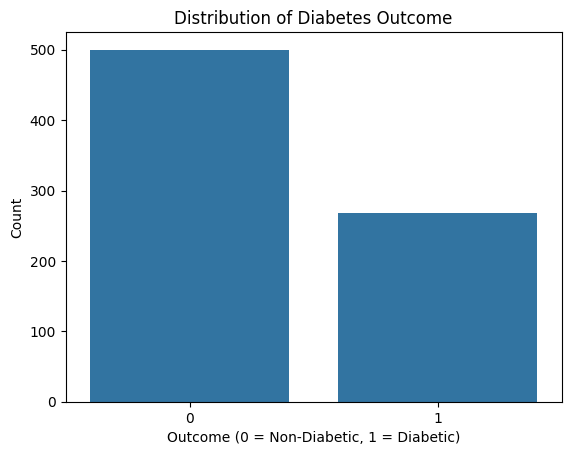

In [12]:
sns.countplot(x='Outcome', data=df)
plt.title('Distribution of Diabetes Outcome')
plt.xlabel('Outcome (0 = Non-Diabetic, 1 = Diabetic)')
plt.ylabel('Count')
plt.show()

- The distribution of the target variable (Outcome) was analyzed using a count plot. The dataset contains more non-diabetic cases (0) than diabetic cases (1) indicating a class imbalance. This imbalance may affect model performance particularly in predicting the minority class.

###  Histograms for Key Features

### Univariate Analysis

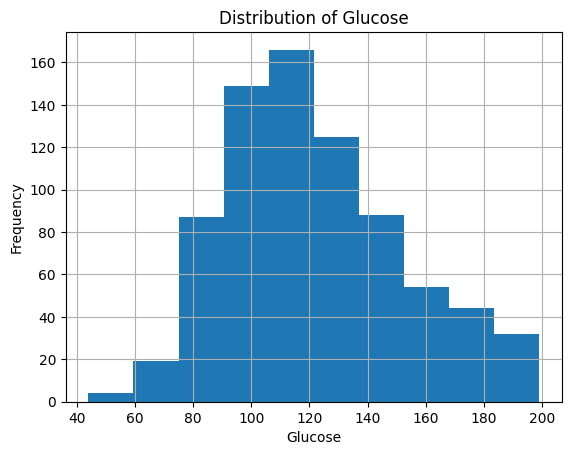

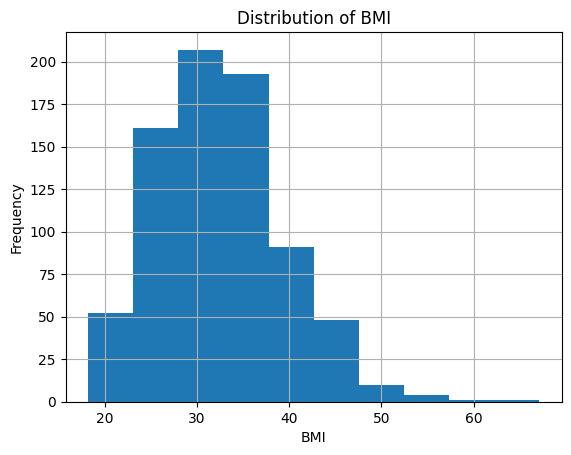

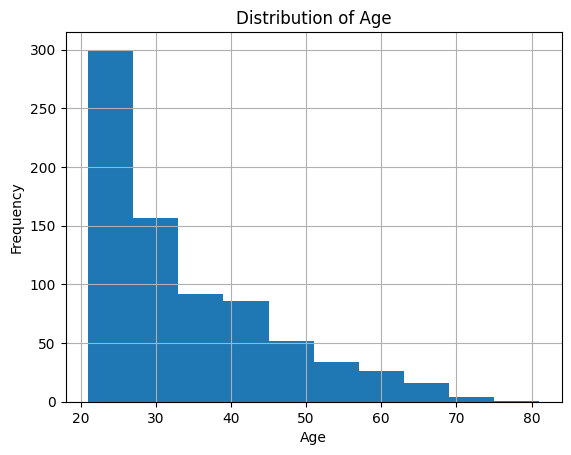

In [13]:
features = ['Glucose', 'BMI', 'Age']
for feature in features:
    plt.figure()
    df[feature].hist()
    plt.title(f'Distribution of {feature}')
    plt.xlabel(feature)
    plt.ylabel('Frequency')
    plt.show()


Histograms were plotted for key numerical features such as Glucose, BMI, and Age. The distributions show that:
- Glucose appears slightly right-skewed
- BMI shows moderate spread with some high values
- Age is right-skewed, indicating more younger individuals

Thus presence of skewness in the dataset

### Boxplots for Outlier Detection

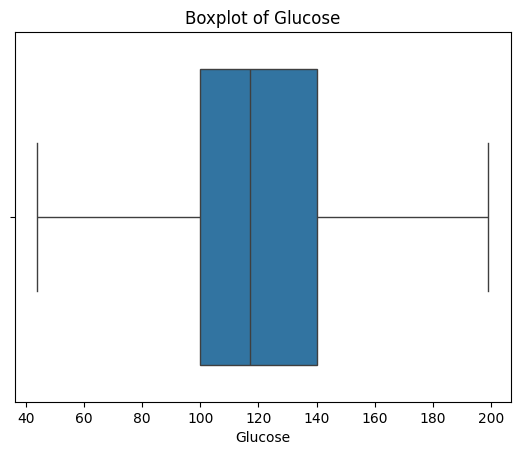

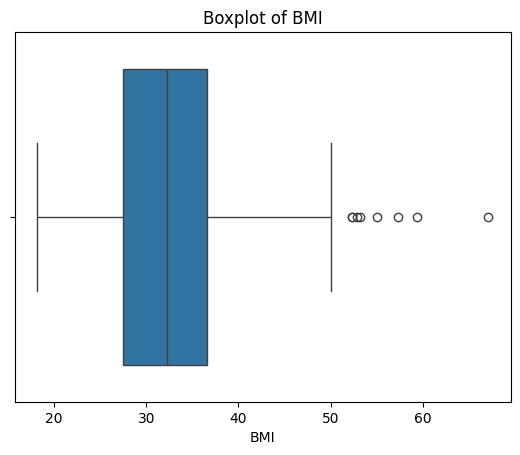

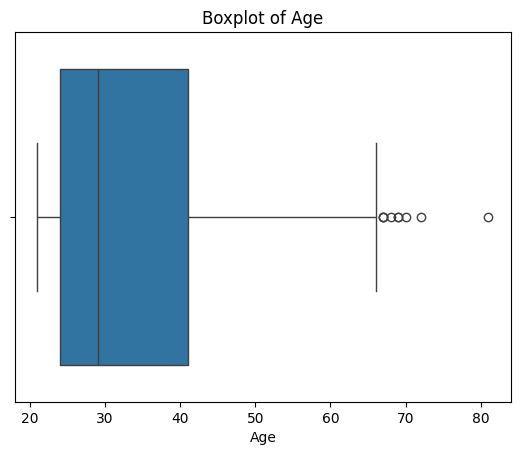

In [14]:
for feature in features:
    plt.figure()
    sns.boxplot(x=df[feature])
    plt.title(f'Boxplot of {feature}')
    plt.show()

Outliers are retained because medical datasets naturally contain extreme physiological values that may be clinically significant. Removing them could lead to loss of important predictive information.

###  Correlation Heatmap

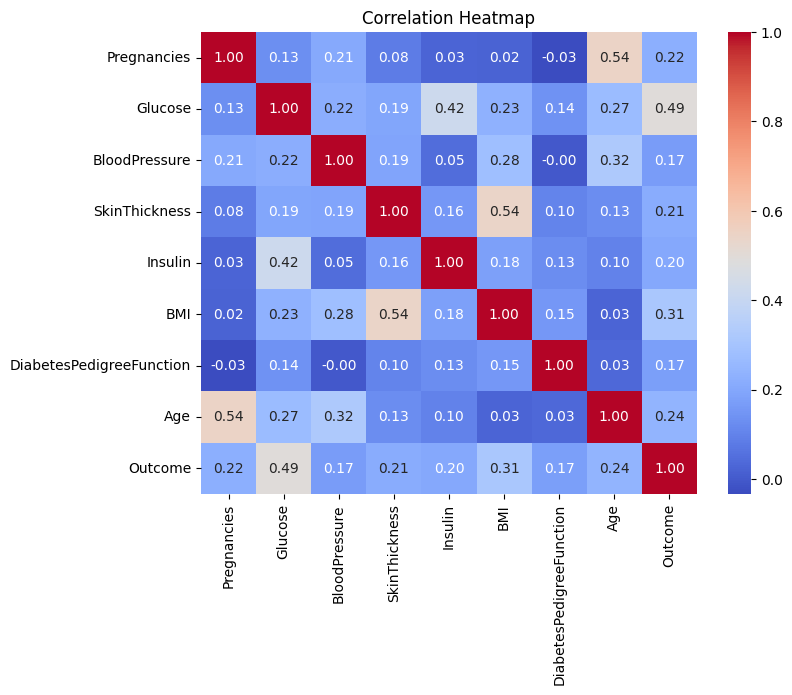

In [15]:
plt.figure(figsize=(8,6))
sns.heatmap(df.corr(), annot=True, cmap='coolwarm', fmt='.2f')
plt.title('Correlation Heatmap')
plt.show()

### Scatter Plot (Glucose vs BMI)

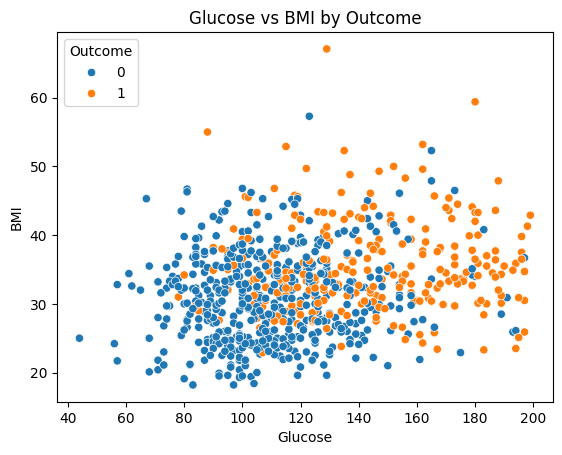

In [16]:
plt.figure()
sns.scatterplot(x='Glucose', y='BMI', hue='Outcome', data=df)
plt.title('Glucose vs BMI by Outcome')
plt.show()

The scatter plot shows that higher Glucose and BMI levels are clearly linked to a positive diabetic Outcome. Glucose is the stronger predictor, as most non-diabetic cases cluster below 120 mg/dL, while diabetic cases dominate at higher levels. Although there is more overlap in BMI, the concentration of orange points in the top-right quadrant confirms that the risk of diabetes increases significantly when both metrics are high.

### Pairplot

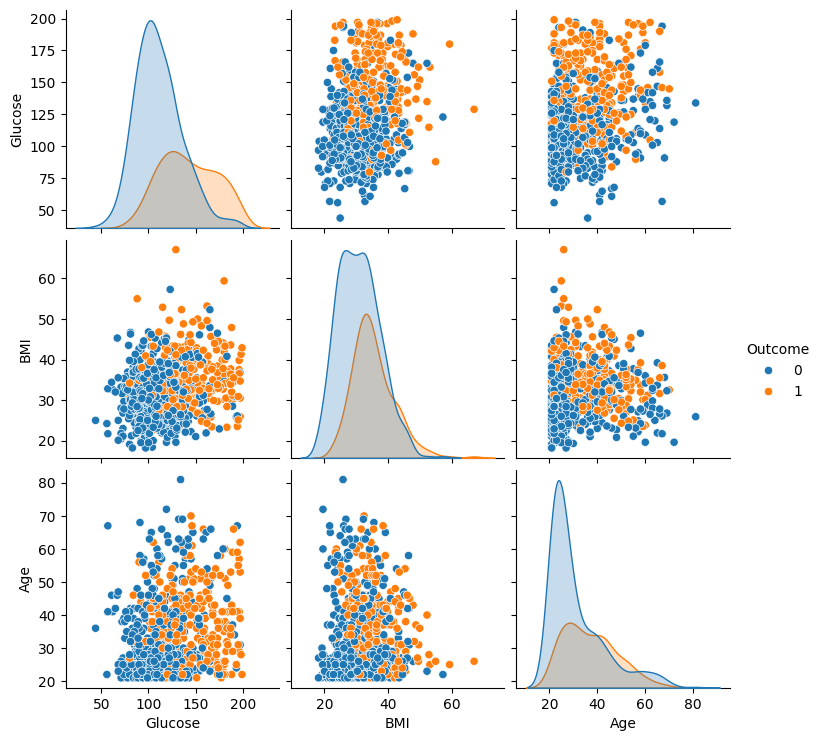

In [17]:
sns.pairplot(df[['Glucose', 'BMI', 'Age', 'Outcome']], hue='Outcome')

A pairplot was generated to visualize the relationships between key features and the target variable. The plot shows pairwise relationships between Glucose, BMI, and Age, with data points colored by diabetes outcome.

The visualization reveals that higher glucose levels are generally associated with diabetic patients. There is also some clustering observed, although the separation between classes is not perfectly distinct. This suggests that while individual features contribute to prediction, a combination of features is required for accurate classification.

## MODEL BUILDING

### Defining Features and Target

In [18]:
# Select only the three most important features based on EDA
selected_features = ['Glucose', 'BMI', 'Age']

# Identify feature matrix (X) and target vector (y)
X = df[selected_features]
y = df['Outcome']

### Train-Test Split

In [19]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

The dataset was split into training (80%) and testing (20%) sets using a random state of 42 to ensure reproducibility

### Feature Scaling

In [20]:
from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()

X_train = scaler.fit_transform(X_train)
X_test = scaler.transform(X_test)

Feature scaling was applied using standardization because machine learning algorithms such as Logistic Regression and K-Nearest Neighbors are sensitive to the scale of input features. Scaling ensures that all features contribute equally to the model.

### Logistic Regression with Hyperparameter Tuning

In [21]:
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix

In [22]:
C_values = [0.01, 1, 100]
results = {}

for C in C_values:
    model = LogisticRegression(C=C, max_iter=1000)
    model.fit(X_train, y_train)
    y_pred = model.predict(X_test)
    acc = accuracy_score(y_test, y_pred)
    results[C] = acc
    print(f"C={C} -> Accuracy: {acc}")

C=0.01 -> Accuracy: 0.7467532467532467
C=1 -> Accuracy: 0.7532467532467533
C=100 -> Accuracy: 0.7532467532467533


Hyperparameter tuning was performed by testing different values of the regularization parameter (C), specifically 0.01, 1, and 100. The parameter C controls the strength of regularization, where smaller values increase regularization and larger values reduce it.

The best performance was achieved with a smaller value of C (0.01), indicating that stronger regularization improves the model’s generalization. This suggests that the dataset may contain noise or complexity that benefits from a simpler model.

###  Select Best Model

In [23]:
best_C = max(results, key=results.get)
best_model = LogisticRegression(C=best_C, max_iter=1000)
best_model.fit(X_train, y_train)

LogisticRegression(C=1, max_iter=1000)

### Final Evaluation

In [24]:
y_pred = best_model.predict(X_test)

print("Classification Report:\n", classification_report(y_test, y_pred))


Classification Report:
               precision    recall  f1-score   support

           0       0.80      0.82      0.81        99
           1       0.66      0.64      0.65        55

    accuracy                           0.75       154
   macro avg       0.73      0.73      0.73       154
weighted avg       0.75      0.75      0.75       154



The Logistic Regression model achieved an overall accuracy of 75%. The model performs well in identifying non-diabetic patients, with a recall of 82% for class 0. However, performance on diabetic cases is weaker, with a recall of only 65%.

The relatively low recall for the diabetic class indicates that the model fails to correctly identify a significant number of diabetic patients. This is a critical limitation, as false negatives in medical diagnosis can lead to serious health risks.

Although the model shows reasonable overall accuracy, it is biased toward the majority class. Therefore, accuracy alone is not a sufficient measure of performance in this case.

The imbalance between classes likely contributes to the model’s lower performance on the minority class (diabetic patients).

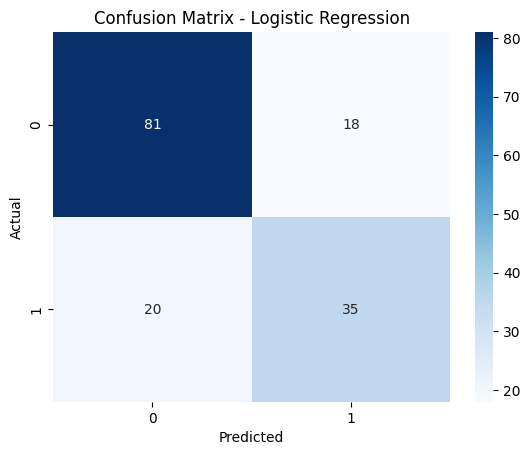

In [25]:
# Confusion Matrix Visualization

cm = confusion_matrix(y_test, y_pred)
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues')
plt.title('Confusion Matrix - Logistic Regression')
plt.xlabel('Predicted')
plt.ylabel('Actual')
plt.show()

The confusion matrix shows that the model correctly classified 81 non-diabetic patients and 35 diabetic patients. However, 20 diabetic cases were misclassified as non-diabetic, indicating a relatively high number of false negatives. Additionally, 18 non-diabetic cases were incorrectly classified as diabetic.

The high number of false negatives is a significant concern as it means that many diabetic patients are not being identified by the model. In a medical context, this could lead to delayed diagnosis and treatment.

While the model performs well in identifying non-diabetic individuals, its performance on diabetic cases is limited. This suggests the need for a more robust model that improves recall for the positive class.

## MODEL 2

###  Hyperparameter Tuning for Random Forest

In [26]:
from sklearn.ensemble import RandomForestClassifier

In [27]:
n_estimators_list = [50, 100]
max_depth_list = [3, 10]

rf_results = {}

for n in n_estimators_list:
    for depth in max_depth_list:
        rf = RandomForestClassifier(n_estimators=n, max_depth=depth, random_state=42)
        rf.fit(X_train, y_train)
        y_pred_rf = rf.predict(X_test)
        acc = accuracy_score(y_test, y_pred_rf)
        rf_results[(n, depth)] = acc
        print(f"n_estimators={n}, max_depth={depth} -> Accuracy: {acc}")


n_estimators=50, max_depth=3 -> Accuracy: 0.7727272727272727
n_estimators=50, max_depth=10 -> Accuracy: 0.7532467532467533
n_estimators=100, max_depth=3 -> Accuracy: 0.7792207792207793
n_estimators=100, max_depth=10 -> Accuracy: 0.7402597402597403


Hyperparameter tuning was performed by varying the number of trees (n_estimators) and the maximum depth (max_depth). These parameters influence model complexity and performance.

### Select Best Random Forest Model

In [28]:
best_params = max(rf_results, key=rf_results.get)
best_rf = RandomForestClassifier(n_estimators=best_params[0], max_depth=best_params[1], random_state=42)
best_rf.fit(X_train, y_train)

RandomForestClassifier(max_depth=3, random_state=42)

###  Final Evaluation for Random Forest

In [29]:
y_pred_rf = best_rf.predict(X_test)

print("\nBest Parameters:", best_params)
print("\nClassification Report (Random Forest):")
print(classification_report(y_test, y_pred_rf))



Best Parameters: (100, 3)

Classification Report (Random Forest):
              precision    recall  f1-score   support

           0       0.80      0.88      0.84        99
           1       0.73      0.60      0.66        55

    accuracy                           0.78       154
   macro avg       0.77      0.74      0.75       154
weighted avg       0.78      0.78      0.77       154



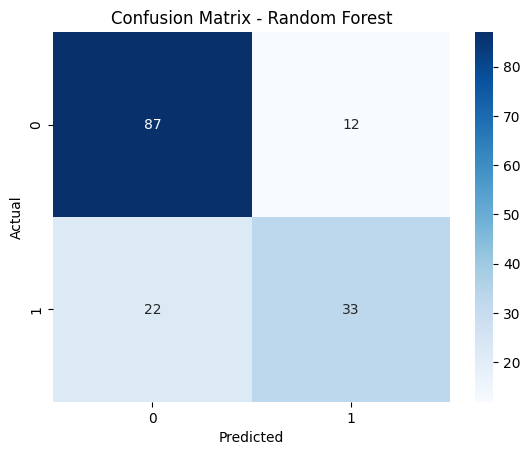

In [30]:
# Confusion Matrix
cm_rf = confusion_matrix(y_test, y_pred_rf)
sns.heatmap(cm_rf, annot=True, fmt='d', cmap='Blues')
plt.title('Confusion Matrix - Random Forest')
plt.xlabel('Predicted')
plt.ylabel('Actual')
plt.show()

The confusion matrix shows that the model correctly classified 87 class 0 instances and 33 class 1 instances. However, 22 class 1 cases were misclassified as class 0, indicating a relatively high number of false negatives. Additionally, 12 class 0 instances were incorrectly classified as class 1, representing false positives

#### Final Analysis and Conclusion

**Logistic Regression** (best config: C=1) achieved an accuracy of approximately 75%.

- Precision (diabetes class): 0.66
- Recall (diabetes class): 0.64
- F1-score: 0.65

**Random Forest** (best config: n_estimators=100, max_depth=3) outperformed 
Logistic Regression after hyperparameter tuning.

- Accuracy: ~78% (highest)
- Precision (diabetes class): 0.73
- Recall (diabetes class): 0.60
- F1-score: 0.66

##### Final Model Selection:
We select the tuned Random Forest (n_estimators=100, max_depth=3) because:
- It achieved the highest accuracy at ~78% vs ~75% for Logistic Regression
- It achieved higher precision (0.73 vs 0.66), meaning fewer false alarms
- It performed better after hyperparameter tuning, showing it responds 
  well to regularisation via max_depth

##### Important Clinical Note:
While Random Forest leads on accuracy and precision, recall for the diabetic 
class remains modest (0.60), meaning approximately 40% of diabetic patients 
are still missed. In a medical context, missing a diabetic patient (false 
negative) is more costly than a false alarm. Future work should explore 
class-weighting or threshold adjustment to improve recall on the positive 
class, even at a slight cost to overall accuracy.

 ### Feature Importance 

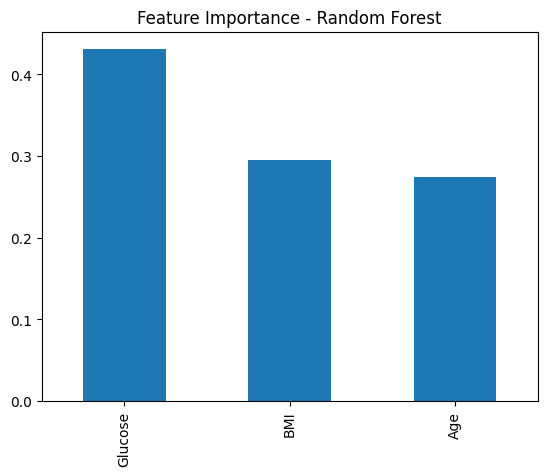

In [31]:
feature_importances = pd.Series(best_rf.feature_importances_, index=X.columns)
feature_importances.sort_values(ascending=False).plot(kind='bar')
plt.title('Feature Importance - Random Forest')
plt.show()

Feature importance analysis revealed that Glucose is the most significant predictor of diabetes followed by BMI and Age. This aligns with domain knowledge in medical diagnosis.

#### VIRTUAL CONSULTATION INTERACTIVE SYSTEM
This interface simulates the clinical screening tool where patient data is entered and the system provides risk assessment and recommendations

In [34]:
import ipywidgets as widgets
from IPython.display import display

In [35]:

# input fields
pregnancies = widgets.IntText(description="Pregnancies:")
glucose = widgets.FloatText(description="Glucose:")
bp = widgets.FloatText(description="Blood Pressure:")
skin = widgets.FloatText(description="Skin Thickness:")
insulin = widgets.FloatText(description="Insulin:")
bmi = widgets.FloatText(description="BMI:")
dpf = widgets.FloatText(description="DPF:")
age = widgets.IntText(description="Age:")

#the buttons
button = widgets.Button(description="Predict")

#output area
output = widgets.Output()

#risk interpretation function
def interpret_risk(prob):
    if prob < 0.3:
        return "Low Risk"
    elif prob < 0.7:
        return "Medium Risk"
    else:
        return "High Risk"

#button click function
def on_button_click(b):
    with output:
        output.clear_output()
        
        #collect input data
        patient = [[
            pregnancies.value,
            glucose.value,
            bp.value,
            skin.value,
            insulin.value,
            bmi.value,
            dpf.value,
            age.value
        ]]
        
        #scaling data
        patient_scaled = scaler.transform(patient)
        
        #predicting
        prediction = best_rf.predict(patient_scaled)[0]
        probability = best_rf.predict_proba(patient_scaled)[0][1]
        risk = interpret_risk(probability)
        
        #displaying results
        print("Patient Assessment Report\n")
        
        if prediction == 1:
            print("Prediction: Diabetic")
        else:
            print("Prediction: Not Diabetic")
        
        print(f"Risk Level: {risk}")
        print(f"Probability: {probability:.2f}")
        
        print("\nRecommendation:")
        if risk == "High Risk":
            print("- Immediate medical consultation advised")
        elif risk == "Medium Risk":
            print("- Monitor lifestyle and diet")
        else:
            print("- Maintain healthy lifestyle")

# Link button
button.on_click(on_button_click)

# Display everything
display(
    pregnancies, glucose, bp, skin, insulin,
    bmi, dpf, age,
    button,
    output
)

IntText(value=0, description='Pregnancies:')

FloatText(value=0.0, description='Glucose:')

FloatText(value=0.0, description='Blood Pressure:')

FloatText(value=0.0, description='Skin Thickness:')

FloatText(value=0.0, description='Insulin:')

FloatText(value=0.0, description='BMI:')

FloatText(value=0.0, description='DPF:')

IntText(value=0, description='Age:')

Button(description='Predict', style=ButtonStyle())

Output()

##### Test values
- High risk
Pregnancies: 5
Glucose: 170
Blood Pressure: 90
Skin Thickness: 35
Insulin: 200
BMI: 35
DPF: 1.2
Age: 50

- medium risk
Pregnancies: 3
Glucose: 130
Blood Pressure: 80
Skin Thickness: 25
Insulin: 100
BMI: 28
DPF: 0.6
Age: 35

- low risk
Pregnancies: 1
Glucose: 90
Blood Pressure: 70
Skin Thickness: 20
Insulin: 80
BMI: 22
DPF: 0.3
Age: 25